# MVP Análise de Dados e Boas Práticas

**Nome:** Rafael Henrique da Costa

**Matrícula:** 4052025002012

**Dataset:** [Titanic Dataset](https://www.kaggle.com/c/titanic/data?select=train.csv)

# Descrição do Problema

## Descrição do Problema

O naufrágio do RMS Titanic ocorreu em 1912 após a colisão do navio com um iceberg durante sua viagem inaugural. Devido à quantidade limitada de botes salva-vidas disponíveis, muitos passageiros e tripulantes não sobreviveram ao desastre.

O dataset Titanic reúne informações sobre passageiros do navio, incluindo características como idade, sexo, classe da passagem, número de familiares a bordo, tarifa paga e porto de embarque.

A partir dessas informações, o problema consiste em prever se um passageiro sobreviveu ou não ao desastre.

Assim, por meio de técnicas de análise exploratória de dados, busca-se identificar padrões e relações entre as variáveis que possam ajudar a explicar a sobrevivência dos passageiros. Essa etapa também permite compreender melhor a estrutura e o comportamento dos dados, auxiliando na definição das etapas adequadas de pré-processamento, de forma a preparar o conjunto de dados para uma possível aplicação futura em modelos de aprendizado de máquina.

## Hipóteses do Problema

As hipóteses que tracei são as seguintes:

1. **Sexo do passageiro e classe da passagem pode influenciar a sobrevivência? Pois historicamente houve prioridade para mulheres, crianças e passageiros de classes mais altas.**

2. **Idade pode influenciar? Pois crianças podem ter recebido prioridade**

3. **Número de familiares a bordo pode ter impactado as chances de sobrevivência?**

## Tipo de Problema

Este é um problema de **classificação supervisionada**. Dado um conjunto de características (comprimento e largura da sépala, comprimento e largura da pétala), o objetivo é prever se uma pessoa iria sobreviver ou não ao naufrágio do Titanic.

## Seleção de Dados

O dataset Titanic é um conjunto de dados da plataforma Kaggle amplamente conhecida e utilizado na competição *Titanic - Machine Learning from Disaster*. Não é necessária uma etapa de seleção de dados externa, pois o dataset já está curado e pronto para uso.

## Atributos do Dataset

O dataset Titanic contém 891 amostras, com um número variado de sobreviventes e falecidos do desastre. Possui onze atributos:

- ***PassengerId*** (Identificador único de cada passageiro)
- ***Survived*** (Classe de sobrevivência: 0 - Não sobreviveu, 1 - Sobrevivente)
- ***Pclass*** (Classe da passagem: 1 - Primeira classe, 2 - Segunda classe, 3 - terceira classe)
- ***Name*** (Nome do passageiro)
- ***Sex*** (Sexo do passageiro: 0 - Feminino, 1 - Masculino)
- ***Age*** (Idade do passageiro)
- ***SibSp*** (Número de irmãos ou esposos(as) no mesmo barco)
- ***Parch*** (Número de genitores ou filhos no mesmo barco)
- ***Ticket*** (Número do ticket de embarque)
- ***Fare*** (Valor do ticket de embarque)
- ***Embarked*** (Porto no qual o passageiro embarcou)

# Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção consolida todas as importações de bibliotecas necessárias para a análise, visualização e pré-processamento dos dados, bem como o carregamento inicial do dataset Titanic - Kaggle.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [2]:
# guardo o dataset em um dataframe
df = pd.read_csv("https://raw.githubusercontent.com/RafaelWhoa/titanic-analytics/refs/heads/main/train.csv")

# alterando o sexo de female para '0' e male para '1' para utilizar na matriz de correlação+
df['Sex'] = df['Sex'].map({"female": 0, "male": 1})

# criando coluna com o número de componentes da família de cada passageiro
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

In [3]:
# primeiras linhas
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C,2
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,S,2
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,S,1


# Análise de Dados

Nesta etapa de Análise de Dados Exploratória (EDA) sobre o dataset Titanic, visamos entender a distribuição, as relações e as características das variáveis, o que é crucial para as etapas subsequentes de pré-processamento e modelagem.

## Total e Tipo das Instâncias

O dataset Titanic possui 891 instâncias (observações), com instâncias variadas para cada resultado de sobrevivência (0 e 1). As características de medição são de tipo numérico (int ou float), enquanto o atributo 'Survived' é categórico.

In [4]:
print(f"Total de instâncias: {len(df)}")
print("\nTipos de dados por coluna:")
print(df.info())

Total de instâncias: 891

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    int64  
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
 12  FamilySize   891 non-null    int64  
dtypes: float64(2), int64(7), object(4)
memory usage: 90.6+ KB
None


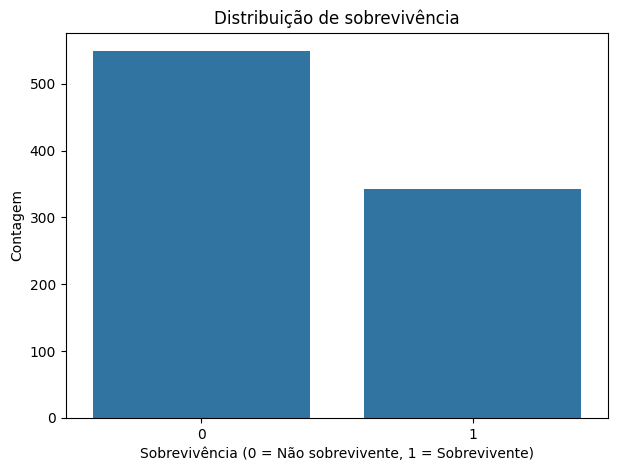

In [5]:
plt.figure(figsize=(7, 5))
# gráfico de barras simples
sns.countplot(x='Survived', data=df)
plt.title('Distribuição de sobrevivência')
plt.xlabel('Sobrevivência (0 = Não sobrevivente, 1 = Sobrevivente)')
plt.ylabel('Contagem')
plt.show()

Para analisar a distribuição da variável **Survived**, foi utilizado um gráfico do tipo **countplot**. Esse tipo de visualização é adequado para variáveis categóricas ou discretas, pois permite observar a frequência absoluta de cada categoria presente no dataset.

No caso do dataset do Titanic, a variável **Survived** é binária, assumindo os valores 0 (não sobrevivente) e 1 (sobrevivente). O uso do countplot possibilita visualizar de forma clara quantos passageiros pertencem a cada uma dessas categorias, permitindo verificar se existe um desequilíbrio entre as classes.

Essa análise é importante na etapa de exploração dos dados, pois a presença de classes desbalanceadas pode influenciar o desempenho de modelos de aprendizado de máquina. A partir do gráfico, foi possível observar que o número de passageiros que não sobreviveram é significativamente maior do que o número de sobreviventes, indicando que o dataset apresenta certo nível de desbalanceamento entre as classes.

## Estatísticas Descritivas

Estatísticas descritivas fornecem um resumo das características numéricas, incluindo média, desvio padrão, mínimo, máximo e quartis.

In [6]:
# estatísticas descritivas básicas do dataset
df.describe()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize
count,891.000000,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,0.647587,29.699118,0.523008,0.381594,32.204208,1.904602
std,257.353842,0.486592,0.836071,0.477990,14.526497,1.102743,0.806057,49.693429,1.613459
min,1.000000,0.000000,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000,1.000000
25%,223.500000,0.000000,2.000000,0.000000,20.125000,0.000000,0.000000,7.910400,1.000000
50%,446.000000,0.000000,3.000000,1.000000,28.000000,0.000000,0.000000,14.454200,1.000000
75%,668.500000,1.000000,3.000000,1.000000,38.000000,1.000000,0.000000,31.000000,2.000000
max,891.000000,1.000000,3.000000,1.000000,80.000000,8.000000,6.000000,512.329200,11.000000


### Média

A média é uma medida de tendência central que representa o valor típico ou o ponto de equilíbrio de um conjunto de dados. É calculada somando-se todos os valores e dividindo-se pelo número total de observações. É sensível a valores extremos (outliers).

In [7]:
# média dos atributos numéricos do dataset
df.describe().loc['mean']

,mean
PassengerId,446.000000
Survived,0.383838
Pclass,2.308642
Sex,0.647587
Age,29.699118
SibSp,0.523008
Parch,0.381594
Fare,32.204208
FamilySize,1.904602


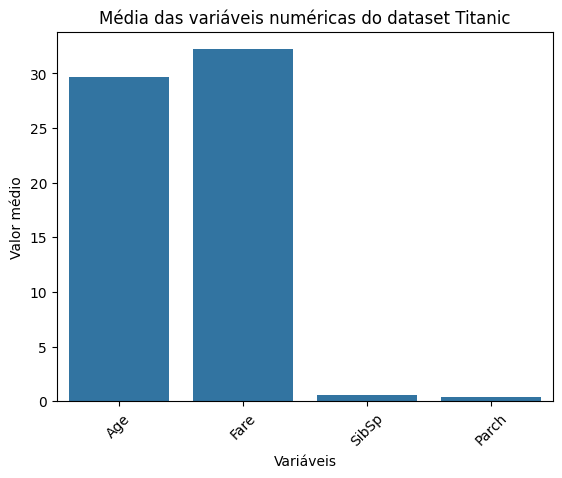

In [8]:
# Qual gráfico seria interessante usar pra mostrar a média?
# Aqui foi utilizado apenas as variáveis numéricas contínuas ou discretas, excluindo as variáveis categóricas como o Pclass por exemplo
dfmean = df[["Age", "Fare", "SibSp", "Parch"]]
means = dfmean.mean()

sns.barplot(x=means.index, y=means.values)

plt.xticks(rotation=45)
plt.title("Média das variáveis numéricas do dataset Titanic")
plt.ylabel("Valor médio")
plt.xlabel("Variáveis")

plt.show()

Para analisar o valor médio das variáveis numéricas **Age**, **Fare**, **SibSp** e **Parch**, foi utilizado um gráfico do tipo **barplot**. Esse tipo de visualização é apropriado para representar e comparar valores agregados entre diferentes categorias ou variáveis, permitindo uma interpretação rápida das diferenças de magnitude entre elas.

Nesse caso, o barplot foi utilizado para exibir a **média de cada uma das variáveis numéricas do dataset**, facilitando a comparação entre seus valores médios. Essa visualização permite identificar, por exemplo, quais variáveis apresentam valores médios mais elevados ou mais baixos, bem como compreender melhor a escala dos dados presentes no conjunto analisado.

A utilização desse gráfico auxilia na etapa de análise exploratória ao fornecer uma visão geral do comportamento médio das variáveis, o que pode contribuir para decisões posteriores relacionadas ao pré-processamento dos dados, como normalização ou padronização.

### Desvio Padrão

O desvio padrão é uma medida de dispersão que quantifica a quantidade de variação ou dispersão de um conjunto de valores. Um desvio padrão baixo indica que os pontos de dados tendem a estar próximos da média do conjunto, enquanto um desvio padrão alto indica que os pontos de dados estão espalhados por uma faixa maior de valores. Ele é a raiz quadrada da variância.

In [9]:
# desvio padrão dos atributos numéricos do dataset
df.describe().loc['std']

,std
PassengerId,257.353842
Survived,0.486592
Pclass,0.836071
Sex,0.477990
Age,14.526497
SibSp,1.102743
Parch,0.806057
Fare,49.693429
FamilySize,1.613459


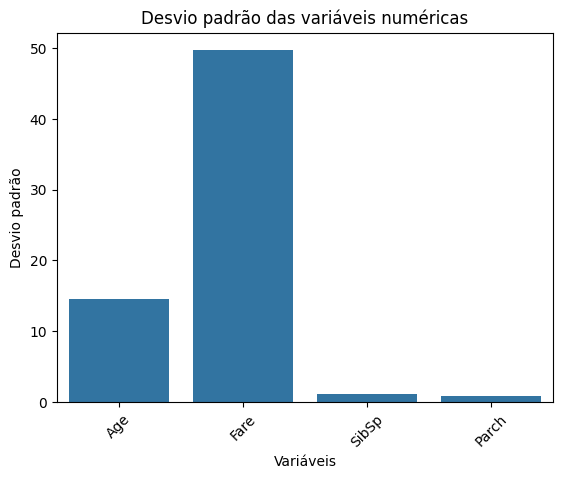

In [10]:
# Qual gráfico seria interessante usar pra mostrar o desvio padrão?
# Aqui foi utilizado apenas as variáveis numéricas contínuas ou discretas, excluindo as variáveis categóricas como o Pclass por exemplo
dfstd = df[["Age", "Fare", "SibSp", "Parch"]]

std = dfstd.std()

sns.barplot(x=std.index, y=std.values)

plt.xticks(rotation=45)
plt.title("Desvio padrão das variáveis numéricas")
plt.ylabel("Desvio padrão")
plt.xlabel("Variáveis")

plt.show()

Para analisar a variabilidade das variáveis numéricas **Age**, **Fare**, **SibSp** e **Parch**, foi utilizado um gráfico do tipo **barplot** representando o **desvio padrão** de cada variável.

A escolha do barplot para essa análise se deve à sua capacidade de **comparar facilmente medidas agregadas entre diferentes variáveis**. Nesse caso, cada barra representa o desvio padrão de uma variável específica, possibilitando identificar quais atributos apresentam maior ou menor variabilidade dentro do conjunto de dados.

Essa visualização contribui para a análise exploratória ao fornecer uma compreensão mais clara da **dispersão dos dados**, permitindo identificar variáveis com grande variação de valores. Essa informação pode ser relevante para etapas posteriores de pré-processamento, como a aplicação de técnicas de padronização ou normalização, especialmente em variáveis com escalas muito diferentes.

## Histograma

A distribuição de dados descreve como os valores de uma variável se espalham, ou seja, a frequência com que diferentes valores ocorrem. Entender a distribuição é crucial na análise de dados, pois revela padrões, tendências centrais, dispersão e a presença de valores atípicos (outliers). O histograma é uma ferramenta visual fundamental para representar essa distribuição, mostrando a forma dos dados, se são simétricos ou assimétricos, unimodais ou multimodais.

### *Idade*

Alguma curiosidade ou fato importante sobre o atributo que estamos olhando a distribuição?

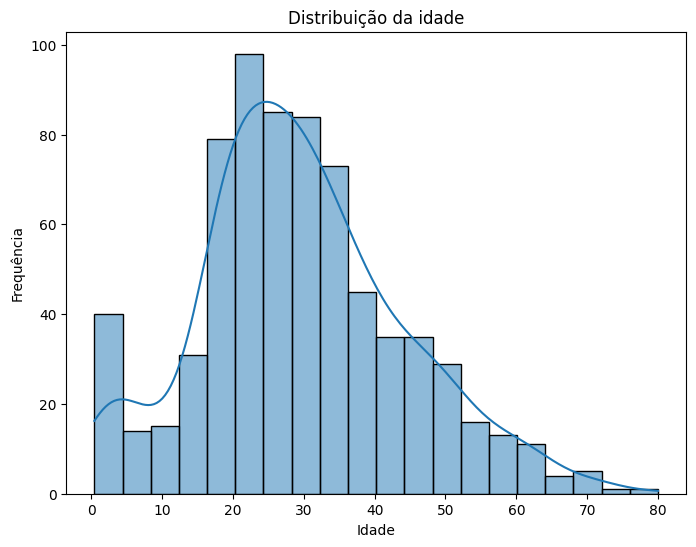

In [11]:
plt.figure(figsize=(8, 6))
# Histograma da idade (um dos atributos)
sns.histplot(df['Age'], kde=True)
plt.title('Distribuição da idade')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.show()

O histograma mostra a distribuição da idade dos passageiros. A curva de densidade estimada (KDE) nos indica que a distribuição parece unimodal, indicando que a maior parte das idades está concentrada em torno de uma faixa específica (20 a 35 anos).

### *Fare*

Alguma curiosidade ou fato importante sobre o atributo que estamos olhando a distribuição?

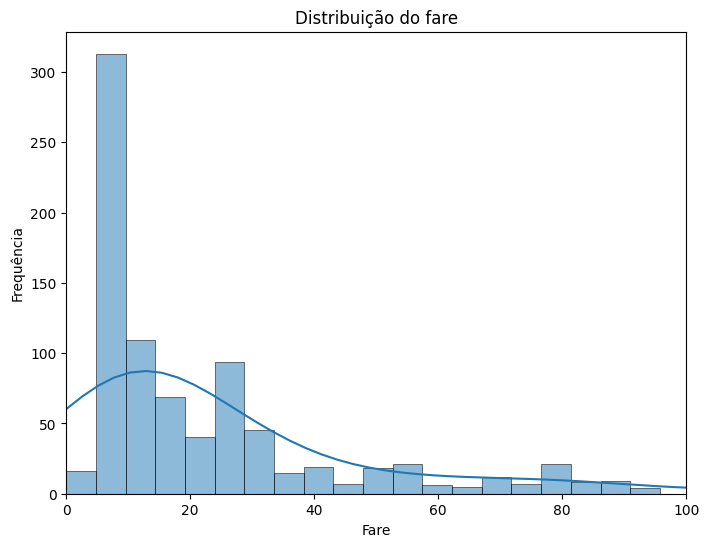

In [12]:
plt.figure(figsize=(8, 6))
# Histograma do fare (um dos atributos)
sns.histplot(df['Fare'], kde=True)
plt.xlim(0, 100)
plt.title('Distribuição do fare')
plt.xlabel('Fare')
plt.ylabel('Frequência')
plt.show()

Quais impressões você tem sobre a distribuição do atributo 'Fare'?

A análise da distribuição da variável Fare mostra forte concentração de valores aproximadamente entre 5 e 20. Esse padrão sugere que grande parte dos passageiros pagou tarifas relativamente baixas, o que pode indicar predominância de passageiros pertencentes às classes inferiores do navio. No entanto, a tarifa não depende exclusivamente da classe, podendo variar também em função do tipo de cabine ou da compra conjunta de passagens.

## Boxplot

Para entender as diferenças entra as possibilidades de sobrevivência, devemos olhar como se comportam os valores quando agrupadas por estado de sobrevivência. Isso nos permite comparar a média, mediana e desvio padrão de cada resultado, além de visualizar suas distribuições por meio de boxplots.


In [13]:
# Estatísticas descritivas agrupadas por espécie
df.groupby('Survived').describe()

PassengerId                                                     \
               count        mean         std  min     25%    50%    75%   
Survived                                                                  
0              549.0  447.016393  260.640469  1.0  211.00  455.0  675.0   
1              342.0  444.368421  252.358840  2.0  250.75  439.5  651.5   

                Pclass            ...  Fare           FamilySize            \
            max  count      mean  ...   75%       max      count      mean   
Survived                          ...                                        
0         891.0  549.0  2.531876  ...  26.0  263.0000      549.0  1.883424   
1         890.0  342.0  1.950292  ...  57.0  512.3292      342.0  1.938596   

                                              
               std  min  25%  50%  75%   max  
Survived                                      
0         1.830669  1.0  1.0  1.0  2.0  11.0  
1         1.186076  1.0  1.0  2.0  3.0   7.0  

[2 rows x 64 columns]

### *petal length* por Espécie


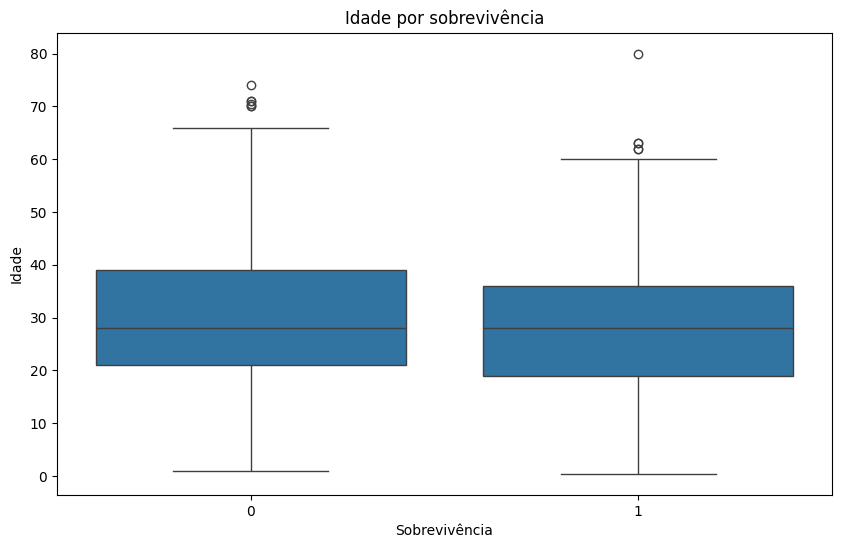

In [14]:
# Boxplot do comprimento da pétala por espécie
plt.figure(figsize=(10, 6))
sns.boxplot(x='Survived', y='Age', data=df)
plt.title('Idade por sobrevivência')
plt.xlabel('Sobrevivência')
plt.ylabel('Idade')
plt.show()

Foi construído um boxplot relacionando a variável **Age** com a variável **Survived**, com o objetivo de verificar se existe diferença significativa na distribuição das idades entre passageiros que sobreviveram e os que não sobreviveram.

Observa-se que as distribuições são bastante semelhantes, apresentando medianas e intervalos interquartis próximos. Isso indica que, isoladamente, a variável **Age** não parece ser um fator fortemente discriminante para a sobrevivência dos passageiros no dataset analisado.


### *Pclass* por Fare

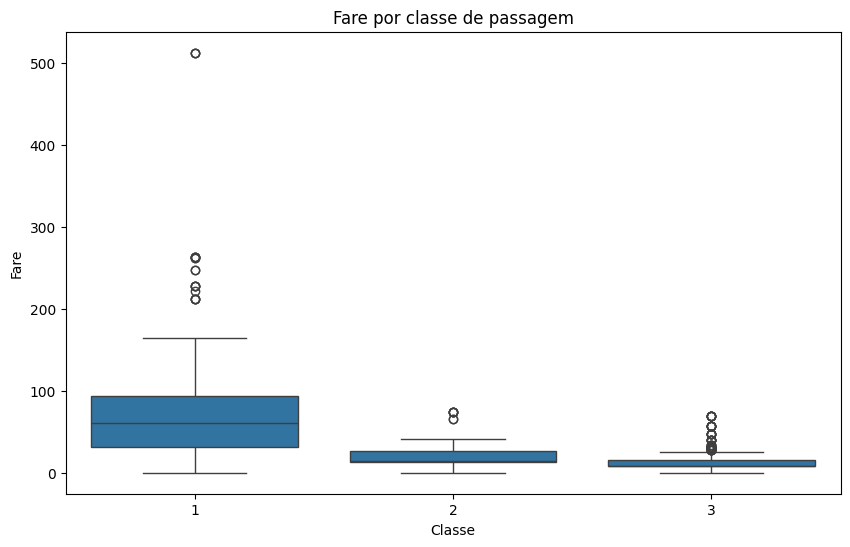

In [15]:
# Boxplot do Fare por classe de passagem
plt.figure(figsize=(10, 6))
sns.boxplot(x='Pclass', y='Fare', data=df)
plt.title('Fare por classe de passagem')
plt.xlabel('Classe')
plt.ylabel('Fare')
plt.show()

Quais impressões o boxplot trouxe?

Ao analisar o boxplot da variável **Fare** em função da variável **Pclass**, observa-se que a **primeira classe apresenta uma variação significativamente maior nas tarifas pagas** em comparação com a segunda e a terceira classes. Isso pode ser observado pela maior amplitude da caixa e pela extensão dos valores no gráfico, indicando maior dispersão nos preços das passagens.

Nas classes segunda e terceira, as tarifas encontram-se mais concentradas em intervalos menores, sugerindo menor variação nos preços pagos pelos passageiros dessas categorias.

Além disso, o gráfico revela a presença de **diversos outliers**, especialmente na primeira e na terceira classe. Esses valores extremos indicam passageiros que pagaram tarifas significativamente diferentes da maioria dentro de suas respectivas classes. Isso pode ocorrer por diversos fatores, como diferenças no tipo de cabine, localização no navio, tamanho do grupo que adquiriu a passagem ou outras condições específicas de compra.

Essa análise evidencia que, embora a classe do passageiro esteja relacionada ao valor da tarifa, existe uma **considerável variabilidade nos preços dentro de cada classe**, particularmente na primeira classe.

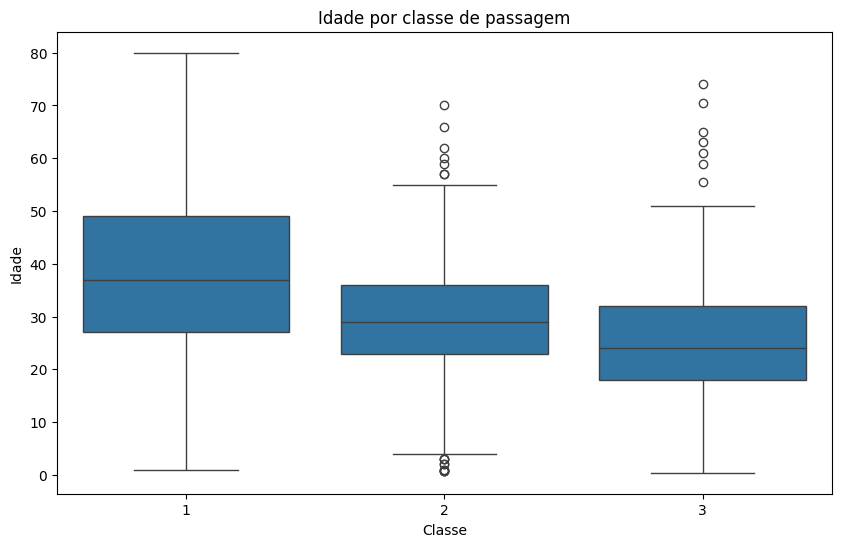

In [16]:
# Boxplot de idade por classe de passagem
plt.figure(figsize=(10, 6))
sns.boxplot(x='Pclass', y='Age', data=df)
plt.title('Idade por classe de passagem')
plt.xlabel('Classe')
plt.ylabel('Idade')
plt.show()

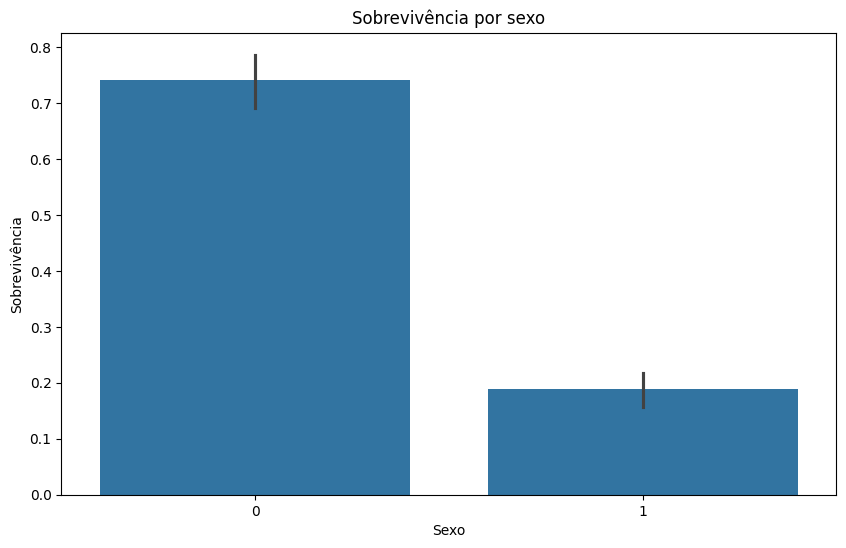

In [17]:
# Barplot sobrevivência por sexo
plt.figure(figsize=(10, 6))
sns.barplot(x='Sex', y='Survived', data=df)
plt.title('Sobrevivência por sexo')
plt.xlabel('Sexo')
plt.ylabel('Sobrevivência')
plt.show()

## Matriz de Correlação

A matriz de correlação mede a força e a direção de uma relação linear que os atributos numéricos das espécies podem ter. Valores próximos a 1 indicam uma forte correlação positiva, -1 uma forte correlação negativa, e 0 ausência de correlação linear.

In [18]:
# Matriz de correlação
print("\nMatriz de Correlação:")
df.corr(numeric_only=True)


Matriz de Correlação:


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize
PassengerId,1.000000,-0.005007,-0.035144,0.042939,0.036847,-0.057527,-0.001652,0.012658,-0.040143
Survived,-0.005007,1.000000,-0.338481,-0.543351,-0.077221,-0.035322,0.081629,0.257307,0.016639
Pclass,-0.035144,-0.338481,1.000000,0.131900,-0.369226,0.083081,0.018443,-0.549500,0.065997
Sex,0.042939,-0.543351,0.131900,1.000000,0.093254,-0.114631,-0.245489,-0.182333,-0.200988
Age,0.036847,-0.077221,-0.369226,0.093254,1.000000,-0.308247,-0.189119,0.096067,-0.301914
SibSp,-0.057527,-0.035322,0.083081,-0.114631,-0.308247,1.000000,0.414838,0.159651,0.890712
Parch,-0.001652,0.081629,0.018443,-0.245489,-0.189119,0.414838,1.000000,0.216225,0.783111
Fare,0.012658,0.257307,-0.549500,-0.182333,0.096067,0.159651,0.216225,1.000000,0.217138
FamilySize,-0.040143,0.016639,0.065997,-0.200988,-0.301914,0.890712,0.783111,0.217138,1.000000


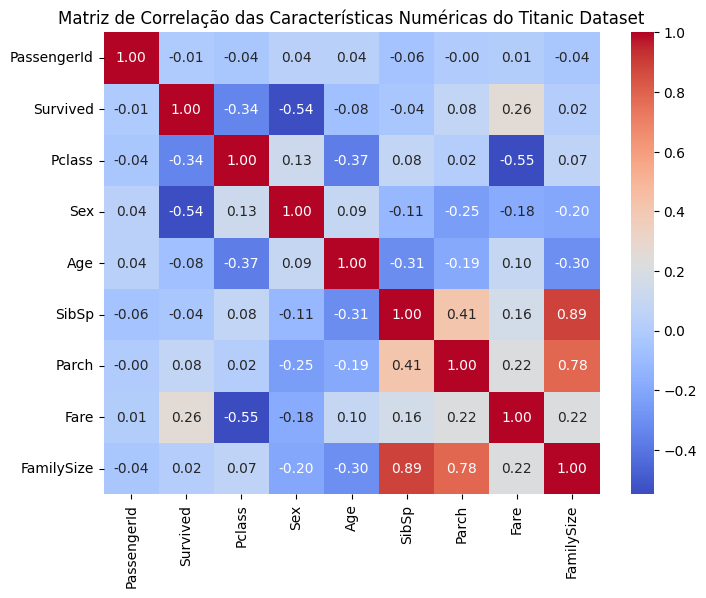

In [19]:
plt.figure(figsize=(8, 6))
# mapa de calor das variáveis numéricas
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação das Características Numéricas do Titanic Dataset')
plt.show()

O mapa de calor da matriz de correlação revela correlações significativas positivas entre *Sex* e *Survived*, bem como entre *Pclass* e *Fare*.

## Tratamento de Valores Nulos

O dataset Titanic possui valores nulos. Portanto, foi utilizado os devidos métodos para tratá-los (preenchimento com média, mediana, moda) ou remoção de linhas/colunas.

In [20]:
# Verificar a presença de valores nulos no dataset original
print("Valores nulos no dataset Titanic:")
df.isnull().sum()

Valores nulos no dataset Titanic:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [21]:
# Exclusão da coluna 'Cabin' por ausência de mais de 70% dos dados e pela dificuldade de extração de significados úteis
df = df.drop(columns=['Cabin'])

# Preenchimento dos dados faltantes de idade pela mediana da coluna 'Age'
df.fillna({'Age': df['Age'].median()}, inplace=True)

# Preenchimento dos dados faltantes de embarque pela moda da colune 'Embarked'
df.fillna({'Embarked': df['Embarked'].mode()[0]}, inplace=True)

In [22]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C,2
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,S,2
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,S,1


In [23]:
# Verificar a presença de valores nulos após tratamento
print("Valores nulos no dataset Titanic:")
df.isnull().sum()

Valores nulos no dataset Titanic:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


# Pré-Processamento de Dados

O pré-processamento de dados é uma etapa crucial para preparar os dados para modelagem, garantindo que estejam no formato correto e otimizados para o desempenho do algoritmo.

In [24]:
# Retirar colunas sem utilidade
df = df.drop(columns=['Name', 'Ticket'])

# Separar features (X) e target (y)
X = df.drop('Survived', axis=1)
y = df['Survived']

In [25]:
# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [26]:
print(f"Dimensões de X_train: {X_train.shape}")
print(f"Dimensões de X_test: {X_test.shape}")
print(f"Dimensões de y_train: {y_train.shape}")
print(f"Dimensões de y_test: {y_test.shape}")

Dimensões de X_train: (623, 9)
Dimensões de X_test: (268, 9)
Dimensões de y_train: (623,)
Dimensões de y_test: (268,)


## Normalização

A técnica de normalização (Min-Max Scaling) foi considerada durante a etapa de pré-processamento. Esse método transforma os valores de uma variável para um intervalo fixo, geralmente entre 0 e 1, sendo útil quando diferentes atributos possuem escalas muito distintas.

No entanto, após análise das variáveis do dataset, observou-se que apenas as variáveis **Age** e **Fare** possuem natureza numérica contínua que justificaria algum tipo de transformação de escala. Nesse caso, optou-se por utilizar **padronização (Standardization)** em vez de normalização, pois esse método é mais apropriado para dados que podem apresentar outliers e distribuições assimétricas.

Dessa forma, a normalização Min-Max não foi aplicada ao dataset, sendo substituída pela padronização das variáveis numéricas relevantes.


## Padronização

A padronização (ou Z-score scaling) transforma os dados para ter média 0 e desvio padrão 1. É útil para algoritmos que são sensíveis à escala das características, como SVMs ou redes neurais.

In [27]:
# Inicializar o StandardScaler
scaler_std = StandardScaler()

In [28]:
# Aprende média e desvio padrão APENAS de X_train
scaler_std.fit(X_train[['Age', 'Fare']])
X_train[['Age', 'Fare']] = scaler_std.transform(X_train[['Age', 'Fare']])
# Usa a média e o desvio padrão aprendidos de X_train
X_test[['Age', 'Fare']] = scaler_std.transform(X_test[['Age', 'Fare']])

In [29]:
# Exibir as primeiras linhas dos dados padronizados (como DataFrame para melhor visualização)
df_standardized = pd.DataFrame(X_train, columns=X_train.columns)

In [30]:
print("\nPrimeiras 5 linhas dos dados padronizados (treino):")
print(df_standardized.head())


Primeiras 5 linhas dos dados padronizados (treino):
     PassengerId  Pclass  Sex       Age  SibSp  Parch      Fare Embarked  \
748          749       1    1 -0.816093      1      0  0.465738        S   
45            46       3    1 -0.126746      0      0 -0.478269        S   
28            29       3    0 -0.126746      0      0 -0.481848        Q   
633          634       1    1 -0.126746      0      0 -0.646954        S   
403          404       3    1 -0.126746      1      0 -0.314823        S   

     FamilySize  
748           2  
45            1  
28            1  
633           1  
403           2  


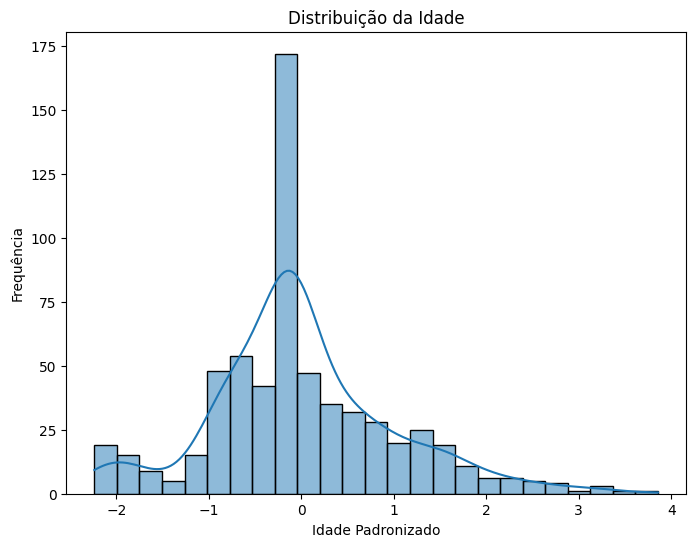

In [31]:
# Visualização da distribuição das idades após a padronização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_standardized['Age'], kde=True)
plt.title('Distribuição da Idade')
plt.xlabel('Idade Padronizado')
plt.ylabel('Frequência')
plt.show()

O histograma de *Age* após a padronização mostra que os valores foram transformados para ter uma média próxima de zero e um desvio padrão de um, centralizando a distribuição.

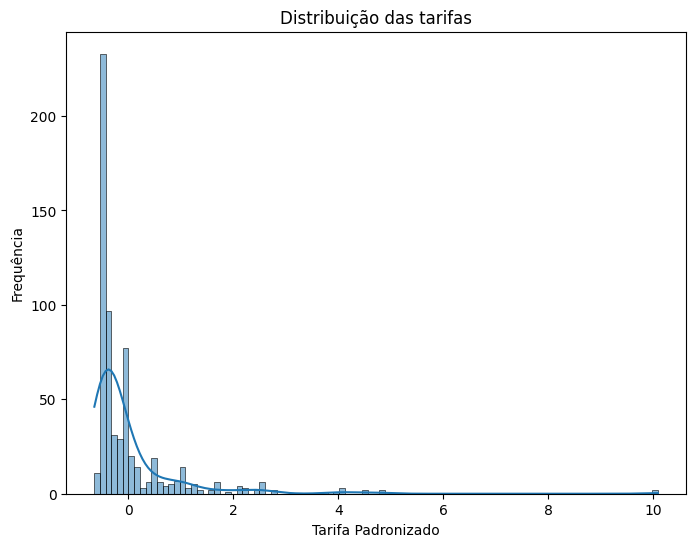

In [32]:
# Visualização da distribuição das tarifas após a padronização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_standardized['Fare'], kde=True)
plt.title('Distribuição das tarifas')
plt.xlabel('Tarifa Padronizado')
plt.ylabel('Frequência')
plt.show()

O histograma de Fare após a padronização mostra que os valores foram transformados para ter uma média próxima de zero e um desvio padrão de um, centralizando a distribuição.

## Outras Transformações e Etapas de Pré-Processamento

Outras etapas de pré-processamento incluem a seleção de características, redução de dimensionalidade (como PCA) ou criação de novas características (feature engineering). O que você faria a mais?



# Respondendo nossas hipóteses

Quais visualizações, tabelas e células descritivas respondem às hipóteses que você levantou?



## Hipótese 1

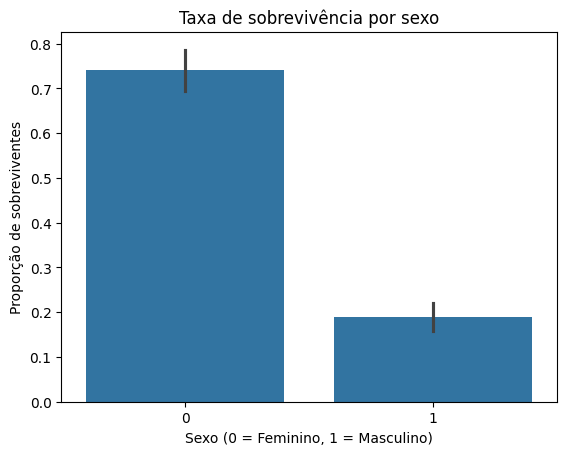

In [33]:
# Sexo do passageiro pode influenciar a sobrevivência? Pois historicamente houve prioridade para mulheres e crianças.

# Barplot de taxa de sobrevivência por sexo
sns.barplot(x='Sex', y='Survived', data=df)

plt.title('Taxa de sobrevivência por sexo')
plt.ylabel('Proporção de sobreviventes')
plt.xlabel('Sexo (0 = Feminino, 1 = Masculino)')
plt.show()

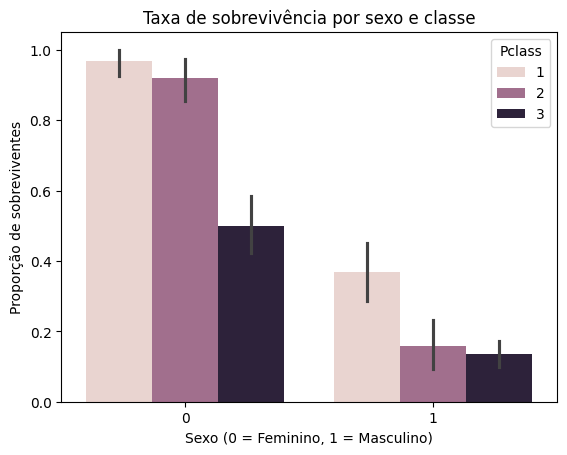

In [34]:
# Barplot de taxa de sobrevivência por sexo e classe
sns.barplot(x="Sex", y="Survived", hue="Pclass", data=df)

plt.title("Taxa de sobrevivência por sexo e classe")
plt.ylabel("Proporção de sobreviventes")
plt.xlabel("Sexo (0 = Feminino, 1 = Masculino)")

plt.show()

Para investigar a hipótese de que o sexo do passageiro influencia a sobrevivência, foi analisada a taxa de sobrevivência por sexo e também a classe do passageiro. O gráfico de barras indica que mulheres apresentaram taxas de sobrevivência significativamente maiores do que homens em todas as classes.

Observa-se também que a classe social teve impacto relevante, uma vez que as mulheres da primeira e segunda classes apresentaram maiores taxas de sobrevivência em comparação com as da terceira classe. Entre os homens, a taxa de sobrevivência foi bastante baixa até mesmo na primeira classe, sendo ainda pior nas demais classes.

In [35]:
# Tabela de contingência

pd.crosstab(df['Sex'], df['Survived'])

Survived,0,1
Sex,,
0,81,233
1,468,109


In [36]:
# Tabela de taxa de sobrevivência
df.groupby('Sex')['Survived'].mean()

,Survived
Sex,
0,0.742038
1,0.188908


<Axes: xlabel='Sex', ylabel='count'>

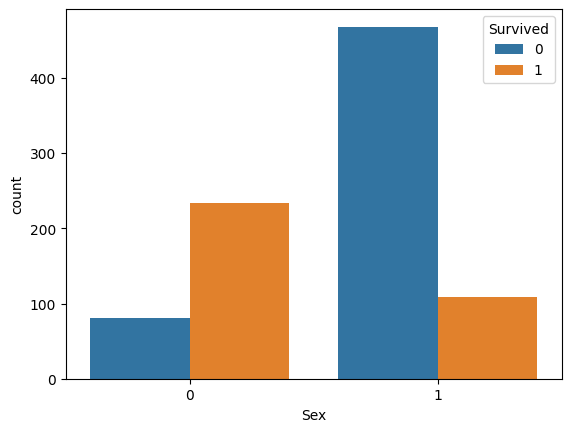

In [37]:
sns.countplot(x='Sex', hue='Survived', data=df)

A análise da relação entre sexo e sobrevivência foi realizada por meio de gráficos e tabelas de frequência. O gráfico de barras da taxa de sobrevivência por sexo indica uma diferença significativa entre homens e mulheres. Observa-se que a proporção de sobrevivência entre mulheres é substancialmente maior do que entre homens. Esse resultado é consistente com o contexto histórico do desastre do RMS Titanic, no qual foi adotada a política de prioridade para mulheres e crianças nos botes salva-vidas.

## Hipótese 2

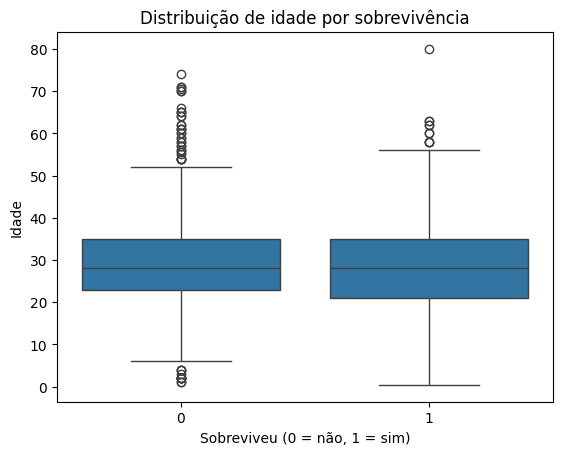

In [38]:
# Idade pode influenciar? Pois crianças podem ter recebido prioridade

# Boxplot de idade por sobrevivência
sns.boxplot(x="Survived", y="Age", data=df)

plt.title("Distribuição de idade por sobrevivência")
plt.xlabel("Sobreviveu (0 = não, 1 = sim)")
plt.ylabel("Idade")

plt.show()

<Axes: xlabel='Age', ylabel='Count'>

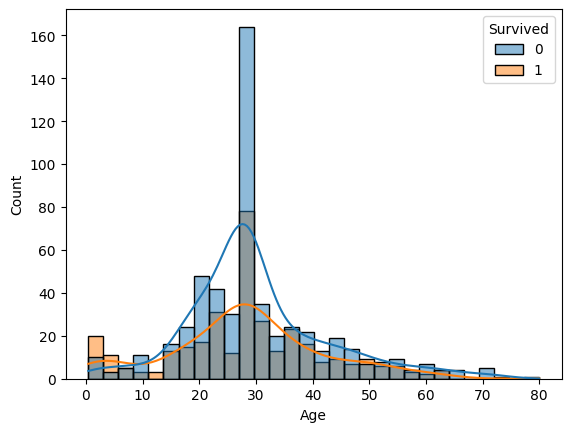

In [39]:
# Histograma separado por sobrevivência
sns.histplot(data=df, x="Age", hue="Survived", bins=30, kde=True)

Observa-se que no início do histograma é a única parte onde a linha laranja está por cima da linha azul, indicando que na faixa entre 0 e 10 anos teve mais sobreviventes do que não sobreviventes.

<Axes: xlabel='AgeGroup', ylabel='Survived'>

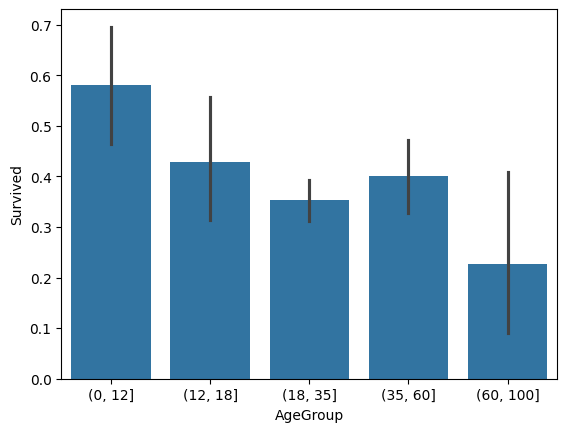

In [40]:
# Barplot com faixas etárias
df["AgeGroup"] = pd.cut(df["Age"], bins=[0,12,18,35,60,100])

sns.barplot(x="AgeGroup", y="Survived", data=df)

Observa-se que o grupo de pessoas entre 0 e 12 anos possuem uma proporção maior de sobrevivência.

In [41]:
# Tabela descritiva útil
df.groupby("Survived")["Age"].describe()

,count,mean,std,min,25%,50%,75%,max
Survived,,,,,,,,
0,549.0,30.028233,12.499986,1.00,23.0,28.0,35.0,74.0
1,342.0,28.291433,13.764425,0.42,21.0,28.0,35.0,80.0


Para investigar a influência da idade na sobrevivência dos passageiros, foram analisadas as distribuições da variável Age para os grupos de sobreviventes e não sobreviventes. O boxplot e os histogramas indicam que a maioria dos passageiros estava concentrada em faixas etárias adultas. No entanto, observa-se, principalmente no histograma, uma proporção relativamente maior de crianças entre os sobreviventes, o que pode estar relacionado à prioridade dada a mulheres e crianças durante o embarque nos botes salva-vidas.

## Hipótese 3

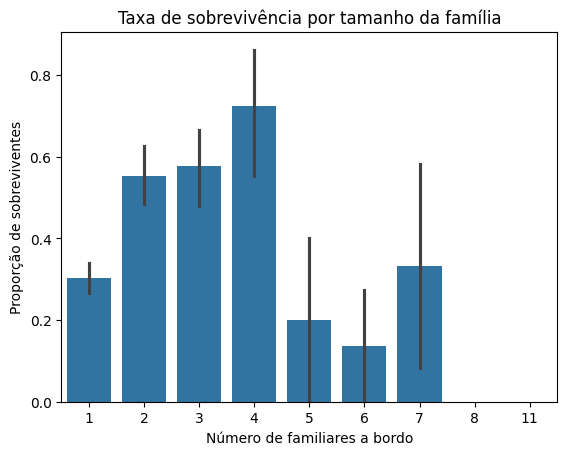

In [42]:
# Número de familiares a bordo pode ter impactado as chances de sobrevivência?

sns.barplot(x="FamilySize", y="Survived", data=df)

plt.title("Taxa de sobrevivência por tamanho da família")
plt.xlabel("Número de familiares a bordo")
plt.ylabel("Proporção de sobreviventes")

plt.show()

<Axes: xlabel='SibSp', ylabel='Survived'>

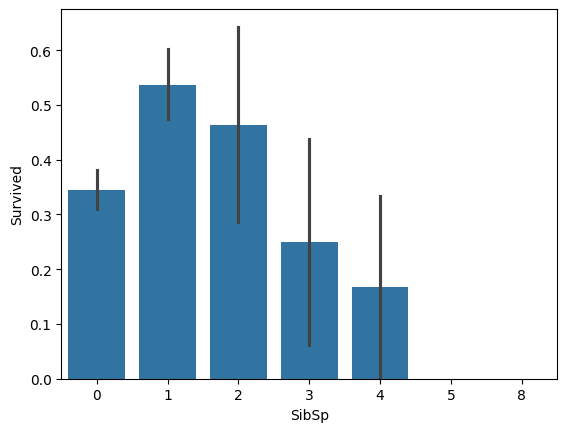

In [43]:
sns.barplot(x="SibSp", y="Survived", data=df)

<Axes: xlabel='Parch', ylabel='Survived'>

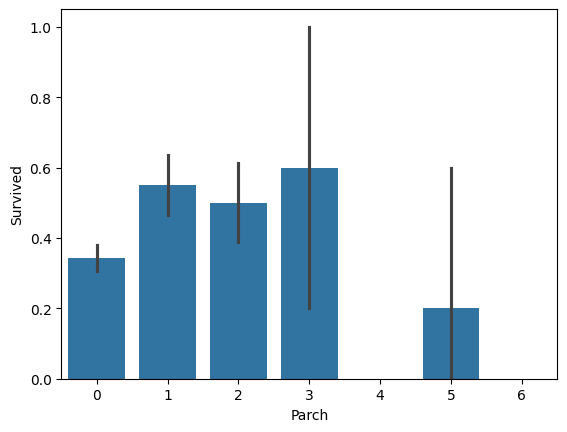

In [44]:
sns.barplot(x="Parch", y="Survived", data=df)

In [45]:
df.groupby("FamilySize")["Survived"].mean()

,Survived
FamilySize,
1,0.303538
2,0.552795
3,0.578431
4,0.724138
5,0.200000
6,0.136364
7,0.333333
8,0.000000
11,0.000000


Para investigar a hipótese de que o número de familiares a bordo pode influenciar a sobrevivência, foi criada a variável FamilySize, representando o tamanho da família do passageiro no navio. A análise da taxa de sobrevivência por tamanho de família indica que passageiros que viajavam com famílias pequenas apresentaram maiores taxas de sobrevivência em comparação com aqueles que viajavam sozinhos ou em famílias muito numerosas. Esse padrão sugere que a presença de um pequeno grupo familiar pode ter facilitado a organização e o acesso aos botes salva-vidas durante a evacuação.

# Conclusão

A análise exploratória e o pré-processamento do dataset do Titanic demonstram a importância de compreender a estrutura e as características dos dados antes da aplicação de modelos de aprendizado de máquina. Durante a etapa de análise, foram identificados valores faltantes em algumas variáveis, que foram tratados por meio de estratégias adequadas, como a substituição pela mediana no caso da variável **Age** e pela moda na variável **Embarked**, além da remoção de atributos com grande quantidade de dados ausentes ou pouco informativos, como **Cabin**, **Name** e **Ticket**.

A análise exploratória revelou padrões relevantes no comportamento dos dados. Foi possível observar, por exemplo, que a variável **Fare** apresenta distribuição assimétrica, com grande concentração de valores em faixas de tarifas mais baixas, indicando que muitos passageiros pertenciam às classes inferiores do navio. Também foram identificadas correlações importantes entre algumas variáveis e a sobrevivência dos passageiros, especialmente em relação ao **sexo**, à **classe do passageiro**, à **idade do passageiro** e à **quantidade de familiares à bordo**.

Além disso, foram aplicadas etapas de padronização nas variáveis numéricas contínuas, como **Age** e **Fare**, com o objetivo de ajustar a escala dos dados e preparar o dataset para possíveis algoritmos de aprendizado de máquina que são sensíveis à escala das variáveis.

As hipóteses levantadas durante a análise foram investigadas e apresentaram evidências nos dados:

**O sexo do passageiro e classe podem influenciar a sobrevivência?**  
Sim. A análise indicou que passageiros do sexo feminino e os de classes mais altas apresentaram taxas de sobrevivência significativamente maiores do que passageiros do sexo masculino e os de classes mais baixas. Esse resultado está de acordo com o contexto histórico do desastre, no qual mulheres e crianças tiveram prioridade no acesso aos botes salva-vidas.

**A idade pode influenciar a sobrevivência?**  
Em certa medida. Embora a distribuição de idades seja relativamente concentrada em adultos, observou-se uma proporção ligeiramente maior de crianças entre os sobreviventes, o que pode estar relacionado à prioridade dada a crianças durante a evacuação.

**O número de familiares a bordo pode impactar as chances de sobrevivência?**  
Os resultados sugerem que passageiros que viajavam com famílias pequenas apresentaram taxas de sobrevivência relativamente maiores em comparação com aqueles que viajavam sozinhos ou em grupos familiares muito grandes. Isso pode indicar que pequenos grupos familiares poderiam facilitar a organização e a evacuação durante o desastre.

De maneira geral, a análise demonstrou que fatores sociais e demográficos, como **sexo**, **classe do passageiro** e **estrutura familiar**, tiveram papel importante nas chances de sobrevivência dos passageiros do Titanic. Esses resultados evidenciam como a análise exploratória de dados pode revelar padrões relevantes antes da aplicação de modelos preditivos.